# Exercise 2 - Monod Kinetics

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### Plots of Biomass concentration X(t) and sunbstrate concentration S(t)

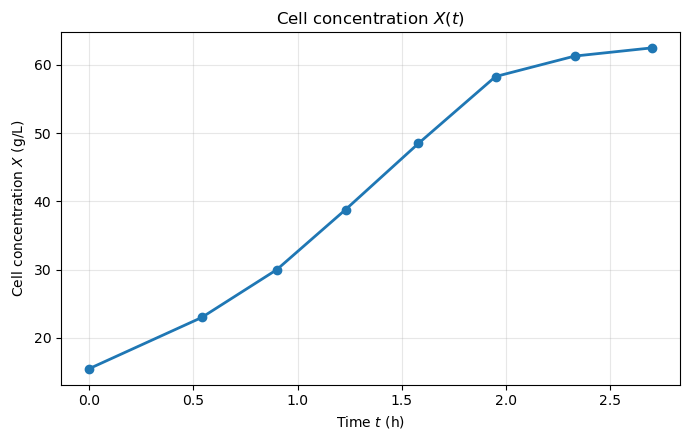

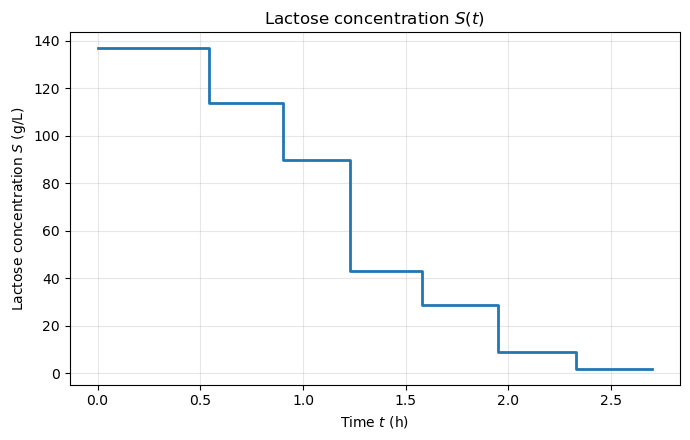

In [2]:
t_start = np.array([0.00, 0.54, 0.90, 1.23, 1.58, 1.95, 2.33])
t_end   = np.array([0.54, 0.90, 1.23, 1.58, 1.95, 2.33, 2.70])

X_start = np.array([15.5, 23.0, 30.0, 38.8, 48.5, 58.3, 61.3])
X_end   = np.array([23.0, 30.0, 38.8, 48.5, 58.3, 61.3, 62.5])

S_const = np.array([137.0, 114.0, 90.0, 43.0, 29.0, 9.0, 2.0])
S = S_const

t_X = np.concatenate(([t_start[0]], t_end))
X_t = np.concatenate(([X_start[0]], X_end))

t_S = np.ravel(np.column_stack([t_start, t_end]))
S_t = np.ravel(np.column_stack([S_const, S_const]))

plt.figure(figsize=(7,4.5))
plt.plot(t_X, X_t, marker="o", linewidth=2)
plt.xlabel("Time $t$ (h)")
plt.ylabel("Cell concentration $X$ (g/L)")
plt.title("Cell concentration $X(t)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("X_vs_time.png", dpi=300)
plt.show()

plt.figure(figsize=(7,4.5))
plt.step(t_S, S_t, where="post", linewidth=2)
plt.xlabel("Time $t$ (h)")
plt.ylabel("Lactose concentration $S$ (g/L)")
plt.title("Lactose concentration $S(t)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("S_vs_time.png", dpi=300)
plt.show()

The evolution of the X(t) curve during the batch culture shows the expected phases of microbial kinetics. In fact, we can see that at the beginning of the experiment (around 0-0.5h), the biomass concentration increases slowly. This is the **lag phase**; cells are adapting to the new environment and are synthesizing the enzymes necessary for lactose metabolism, so their growth is still limited. Then, between 0.5h and 1.9h, the cell concentration increases a lot quicker, almost exponentially, this is the **exponential phase** of microbial kinetics. Here, cells are diving at a constant specific growth rate and substrate concentration is still high, meaning that our growth conditions are optimal. Finally, after 1.9h, the slope decreases considerably. This is the **stationary phase** of microbial kinetics, where the growth rate slows down as the lactose concentration becomes limiting.  

### Lineweaver-Burke type plot 


Interval |   S (g/L) |   mu (1/h)
       1 |    137.0 |    0.8961
       2 |    114.0 |    0.8454
       3 |     90.0 |    0.8889
       4 |     43.0 |    0.7143
       5 |     29.0 |    0.5461
       6 |      9.0 |    0.1354
       7 |      2.0 |    0.0529

--- Lineweaver–Burk Results ---
Used intervals: [2, 3, 4, 5]
mu_max = 1.13999 1/h
K_s    = 29.81615 g/L


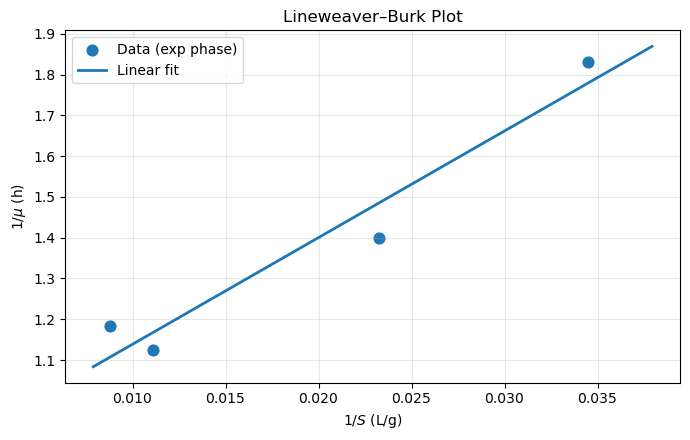

In [3]:
dt = t_end - t_start
dXdt = (X_end - X_start) / dt
mu = dXdt / X_start   

print("\nInterval |   S (g/L) |   mu (1/h)")
for i in range(len(S)):
    print(f"{i+1:>8} | {S[i]:>8.1f} | {mu[i]:>9.4f}")


exp_intervals = [2, 3, 4, 5]   
exp_idx = [k-1 for k in exp_intervals]

S_exp = S[exp_idx]
mu_exp = mu[exp_idx]


x = 1.0 / S_exp
y = 1.0 / mu_exp

m, b = np.polyfit(x, y, 1)

mu_max = 1.0 / b
K_s = m * mu_max

print("\n--- Lineweaver–Burk Results ---")
print(f"Used intervals: {exp_intervals}")
print(f"mu_max = {mu_max:.5f} 1/h")
print(f"K_s    = {K_s:.5f} g/L")


plt.figure(figsize=(7,4.5))
plt.scatter(x, y, s=60, label="Data (exp phase)")
x_line = np.linspace(min(x)*0.9, max(x)*1.1, 200)
plt.plot(x_line, m*x_line + b, linewidth=2, label="Linear fit")

plt.xlabel(r"$1/S$ (L/g)")
plt.ylabel(r"$1/\mu$ (h)")
plt.title("Lineweaver–Burk Plot")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("Lineweaver_Burk.png", dpi=300)
plt.show()

To estimate the Monod parameters, the specific growth rate $\mu$ was first calculated for each time interval using the relation

$$
\mu = \frac{1}{X_{min}}\frac{dX}{dt}
$$

where $X$ is the biomass concentration. The derivative $\frac{dX}{dt}$ was approximated using finite differences between the measured biomass concentrations at the beginning and end of each interval.

Only the points corresponding to the exponential growth phase were used for this plot, since Monod kinetics applies when cells are actively growing and the lag and stationary phases should be neglected. Based on the biomass curve, intervals 2–5 (0.5h-1.9h) were selected.

A Lineweaver–Burk type plot was then constructed by plotting $\frac{1}{\mu}$ versus $\frac{1}{S}$. According to the linearized Monod equation

$$
\frac{1}{\mu} = \frac{K_s}{\mu_{max}}\frac{1}{S} + \frac{1}{\mu_{max}}
$$

the slope corresponds to $\frac{K_s}{\mu_{max}}$ and the intercept corresponds to $\frac{1}{\mu_{max}}$.

From the linear regression of the selected points, the following parameters were obtained:

- $\mu_{max} \approx 1.14\ \text{h}^{-1}$
- $K_s \approx 29.8\ \text{g L}^{-1}$

The value of $\mu_{max}$ represents the maximum possible specific growth rate at very high substrate concentrations, which explains why it can be slightly larger than the individual $\mu$ values measured during the experiment.

### Mass doubling time 

The mass doubling time $t_d$ is the time required fot the mass of the cell to double during the exponential growth phase. During exponential growth, the biomass follows

$$
\frac{dX}{dt} = \mu X
$$

where $X$ is the biomass concentration and $\mu$ is the specific growth rate.

Solving this differential equation gives the exponential growth law

$$
X(t) = X_0 e^{\mu t}
$$

where $X_0$ is the initial biomass concentration.

The doubling time corresponds to the time at which the biomass becomes twice the initial value:

$$
X(t_d) = 2X_0
$$

Substituting into the exponential equation:

$$
2X_0 = X_0 e^{\mu t_d}
$$

Dividing by $X_0$:

$$
2 = e^{\mu t_d}
$$

Taking the natural logarithm:

$$
\ln 2 = \mu t_d
$$

which gives the expression

$$
t_d = \frac{\ln 2}{\mu}
$$

To estimate the doubling time, we assume that the cells grow in the exponential phase, where the growth rate is approximately constant. In this region, the specific growth rate approaches the maximum specific growth rate obtained from the Lineweaver–Burk analysis:

$$
\mu_{max} \approx 1.14 \ \text{h}^{-1}
$$

Therefore,

$$
t_d = \frac{\ln 2}{1.14}
$$

$$
t_d \approx 0.61 \ \text{h}
$$

Thus, the biomass doubles approximately every 0.61 hours (about 37 minutes) during the exponential growth phase.